# Занятие 10. Практика: визуализация данных — АВТОРСКОЕ РЕШЕНИЕ

На прошлом занятии разобрали теорию визуализации: быстрые графики Pandas **`.plot()`**
(`kind='line'/'bar'/'barh'/'hist'/'pie'/'scatter'`), устройство **Matplotlib**
(**`Figure`** и **`Axes`**, `plt.subplots()`, подписи и легенда) и разведочные графики
**Seaborn** (`countplot`, `barplot`, `lineplot`, `histplot`, `scatterplot`, `heatmap`,
параметр `hue`).

Сегодня применяем это к данным интернет-магазина. Сначала **коротко вспомним инструменты**
на знакомом `orders.csv`

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 220)
sns.set_theme(style='whitegrid')

---
## Повторение инструментов

Вспомним приёмы на знакомом `orders.csv` (заказы из прошлого урока).

In [53]:
df = pd.read_csv('data/orders.csv', sep=';')
print('orders.csv:', df.shape)

orders.csv: (1500, 9)


### Столбцы из `value_counts()` — `.plot(kind='bar')`

`value_counts()` возвращает готовый `Series`, его сразу можно нарисовать столбцами:

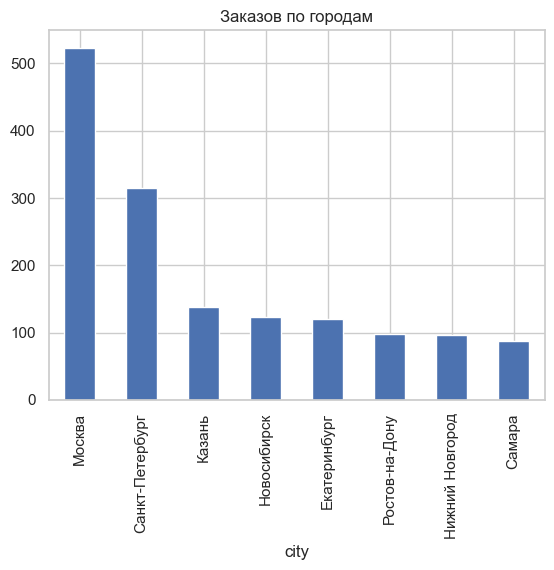

In [54]:
df['city'].value_counts().plot(kind='bar', title='Заказов по городам');

**Вывод:** высота столбца — число заказов в городе; лидер виден сразу.

### Seaborn `barplot` с разбивкой через `hue`

Seaborn сам агрегирует и умеет разбивать по второй категории:

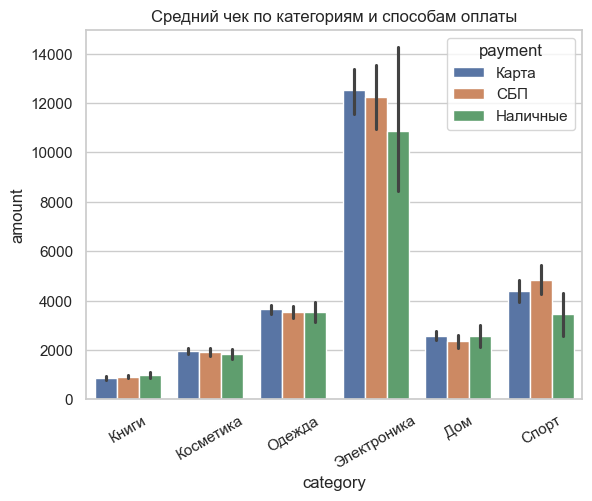

In [55]:
sns.barplot(data=df, x='category', y='amount', hue='payment')
plt.title('Средний чек по категориям и способам оплаты')
plt.xticks(rotation=30);

**Вывод:** высота столбца — средний чек, цвет — способ оплаты; `groupby` вручную не нужен.

### Тепловая карта из `pivot_table`

Двумерную таблицу-матрицу удобно показать `heatmap`:

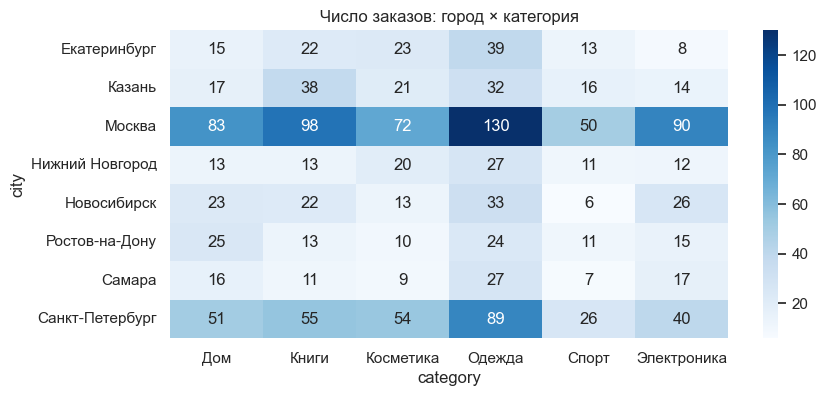

In [56]:
piv = df.pivot_table(index='city', columns='category',
                     values='order_id', aggfunc='count')
plt.figure(figsize=(9, 4))
sns.heatmap(piv, annot=True, fmt='g', cmap='Blues')
plt.title('Число заказов: город × категория');

**Вывод:** цвет клетки — число заказов; горячие клетки видно мгновенно.

---
## Практика

Ниже — **10 заданий** (максимум **30 баллов**). В каждом задании:
- **постройте график** в ячейке `# Ваш код` — код обязателен;
- заполните пункт **Вывод:** — одним-двумя предложениями опишите, **что видно на графике**
  (или что показывает сравнение).

Оцениваются и построенный график, и текстовый вывод.

### Датасет практики — `shop_orders.csv`

**1365 заказов** интернет-магазина, **15 колонок**:

| Столбец | Что это |
|---|---|
| `order_id` | номер заказа |
| `created_at` | дата и время оформления |
| `delivered_at` | дата и время доставки (у части пусто) |
| `customer_id` | клиент |
| `segment` | сегмент клиента: `New` / `Returning` / `VIP` |
| `channel` | канал привлечения: Ads / Organic / Email / Social / Referral |
| `device` | устройство: Mobile / Desktop / Tablet |
| `city` | город |
| `category` | категория товара |
| `payment` | способ оплаты |
| `amount` | сумма заказа, руб. |
| `quantity` | число товаров в заказе |
| `discount_pct` | скидка, % |
| `delivery_days` | срок доставки в днях (у части пусто) |
| `rating` | оценка заказа 1–5 (у части пусто) |

Загружаем датасет и сразу готовим столбец `час` (пригодится для графиков по времени):

In [57]:
df = pd.read_csv('data/shop_orders.csv', sep=';')
df['created_at'] = pd.to_datetime(df['created_at'])
df['delivered_at'] = pd.to_datetime(df['delivered_at'])
df['час'] = df['created_at'].dt.hour
print('shop_orders.csv:', df.shape)
df.head()

shop_orders.csv: (1365, 16)


,order_id,created_at,delivered_at,customer_id,segment,channel,device,city,category,payment,amount,quantity,discount_pct,delivery_days,rating,час
0,1000,2024-01-01 07:48:00,2024-01-01 14:59:00,2231,New,Organic,Mobile,Москва,Книги,СБП,3321,5,0,0.3,4.0,7
1,1001,2024-01-01 10:32:00,NaT,2402,Returning,Social,Desktop,Екатеринбург,Электроника,СБП,46897,4,0,NaN,NaN,10
2,1002,2024-01-01 13:57:00,NaT,2055,Returning,Referral,Mobile,Ростов-на-Дону,Косметика,СБП,6252,4,0,NaN,NaN,13
3,1003,2024-01-01 19:56:00,2024-01-05 00:21:00,2433,Returning,Email,Mobile,Казань,Одежда,Карта,11586,3,0,3.2,5.0,19
4,1004,2024-01-02 13:18:00,2024-01-05 20:17:00,2261,Returning,Email,Desktop,Самара,Дом,СБП,3604,2,15,3.3,NaN,13


### <font color='DarkOrange'>Задание 1 [2 балла]</font>

Постройте **гистограмму** распределения сумм заказов (`amount`). Опишите форму распределения.

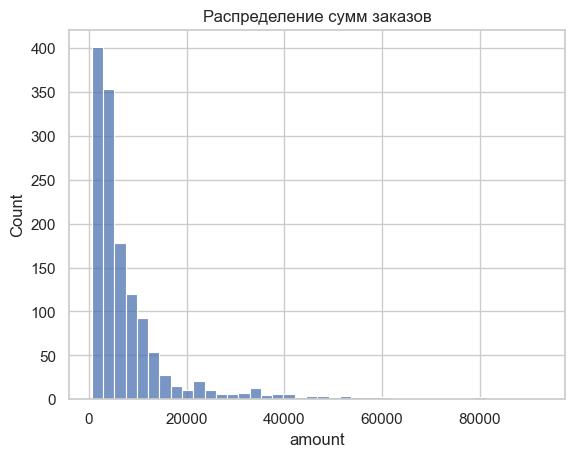

In [58]:
sns.histplot(data=df, x='amount', bins=40)
plt.title('Распределение сумм заказов');
# Ожидаемый результат: распределение сильно скошено вправо;
# большинство заказов недорогие (медиана ~4600), есть длинный хвост до ~93000

**Вывод:** Распределение сильно скошено вправо: большинство заказов недорогие, но редкие крупные покупки тянут длинный правый хвост.

### <font color='DarkOrange'>Задание 2 [2 балла]</font>

Постройте **столбчатую диаграмму** числа заказов по категориям (`category`). Какая категория популярнее всех, какая реже всех?

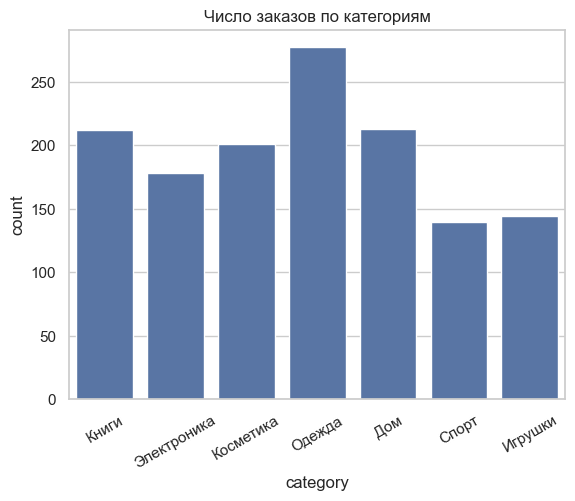

In [59]:
sns.countplot(data=df, x='category')
plt.title('Число заказов по категориям')
plt.xticks(rotation=30);
# Ожидаемый результат: лидер — Одежда (277), меньше всего — Спорт (140)

**Вывод:** Больше всего заказов в категории «Одежда», меньше всего — в «Спорт»; спрос по категориям заметно неравномерен.

### <font color='DarkOrange'>Задание 3 [2 балла]</font>

Постройте **круговую диаграмму** долей заказов по устройствам (`device`); подпишите проценты на секторах. Какое устройство преобладает?

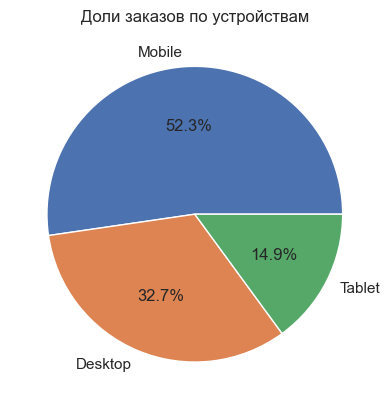

In [60]:
df['device'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                 ylabel='', title='Доли заказов по устройствам');
# Ожидаемый результат: Mobile ~52%, Desktop ~33%, Tablet ~15%

**Вывод:** Больше половины заказов делают с мобильных (~52%), примерно треть — с десктопа, планшеты — меньшинство.

### <font color='DarkOrange'>Задание 4 [3 балла]</font>

Сравните **средний чек по сегментам** клиентов (`segment`: New / Returning / VIP) столбчатой диаграммой. Во сколько примерно VIP дороже New?

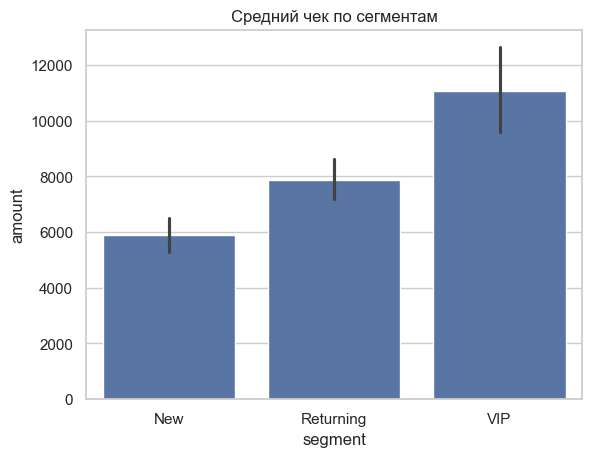

In [61]:
sns.barplot(data=df, x='segment', y='amount')
plt.title('Средний чек по сегментам');
# Ожидаемый результат: New ~5890, Returning ~7885, VIP ~11086 — VIP примерно в 1.9 раза дороже New

**Вывод:** Средний чек растёт от New к VIP: VIP тратят примерно в 1.9 раза больше, чем новые клиенты — сегмент действительно ценный.

### <font color='DarkOrange'>Задание 5 [3 балла]</font>

Постройте столбчатую диаграмму среднего чека **по категориям с разбивкой по сегментам** — столбцы одной категории раскрашены по сегменту (`segment`). В какой категории разрыв между VIP и New самый большой?

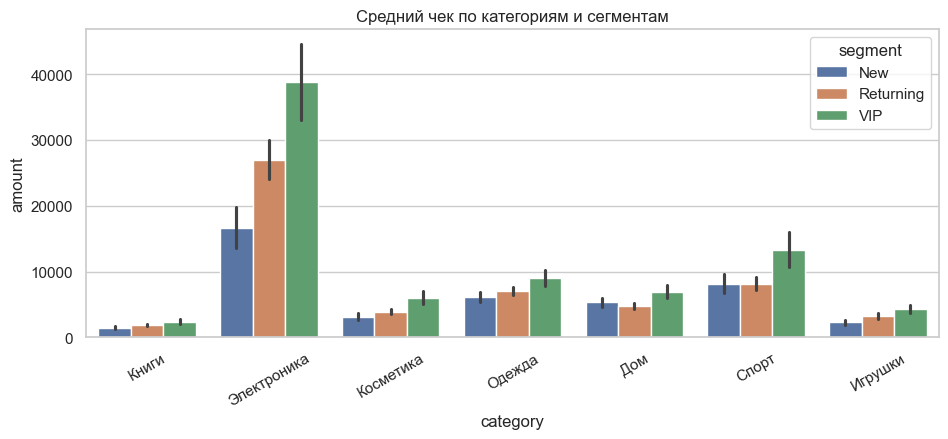

In [62]:
plt.figure(figsize=(11, 4))
sns.barplot(data=df, x='category', y='amount', hue='segment')
plt.title('Средний чек по категориям и сегментам')
plt.xticks(rotation=30);
# Ожидаемый результат: разрыв VIP-New максимален в Электронике (~22000)

**Вывод:** Разрыв между VIP и New сильнее всего в «Электронике»: именно там VIP тратят кратно больше — дорогая техника делает сегмент особенно ценным.

### <font color='DarkOrange'>Задание 6 [3 балла]</font>

Постройте **линейный график** числа заказов по часам суток (`час`); часы по оси X должны идти по порядку от 0 до 23. В какие часы пик заказов?

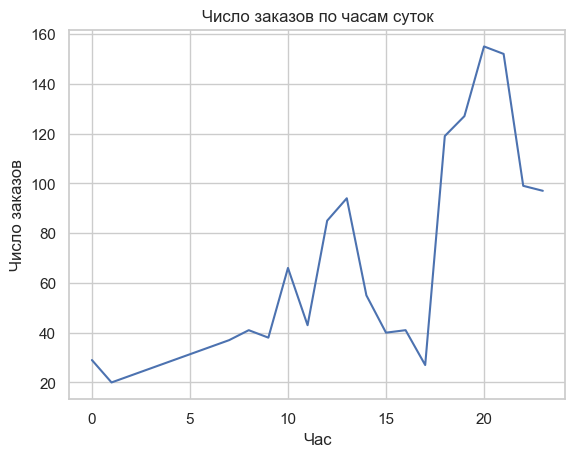

In [63]:
orders_by_hour = df['час'].value_counts().sort_index()
orders_by_hour.plot(title='Число заказов по часам суток')
plt.xlabel('Час'); plt.ylabel('Число заказов');
# Ожидаемый результат: выраженный вечерний пик 18-21 (максимум в 20:00 = 155),
# минимум — ранним утром

**Вывод:** Заказы концентрируются вечером: пик приходится на 18–21 час (максимум около 20:00), а ночью и ранним утром активность минимальна.

### <font color='DarkOrange'>Задание 7 [4 балла]</font>

Разбейте заказы на **две группы**: со скидкой и без (по столбцу `discount_pct`). Сравните группы по **среднему чеку** (`amount`) и **средней корзине** (`quantity`) — двумя столбчатыми графиками. Растёт ли корзина от скидок?

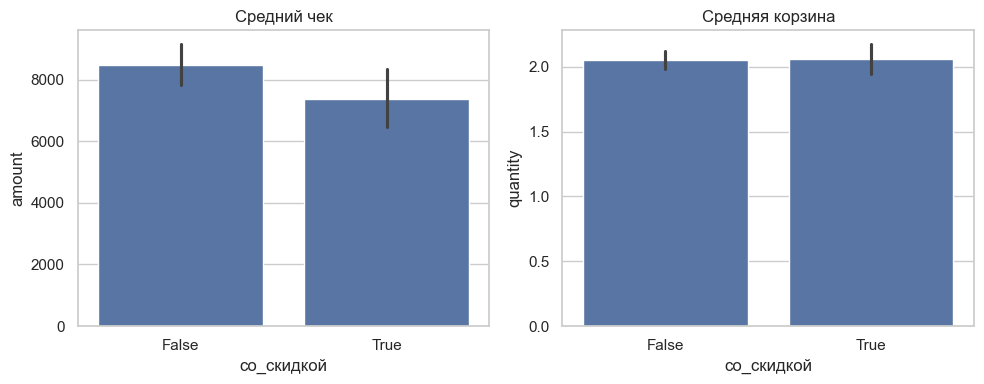

In [64]:
df['со_скидкой'] = df['discount_pct'] > 0

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.barplot(data=df, x='со_скидкой', y='amount', ax=axes[0])
axes[0].set_title('Средний чек')
sns.barplot(data=df, x='со_скидкой', y='quantity', ax=axes[1])
axes[1].set_title('Средняя корзина')
plt.tight_layout();
# Ожидаемый результат: со скидкой средний чек даже НИЖЕ (~7383 vs ~8465),
# а корзина почти одинаковая (~2.1 в обеих группах)

**Вывод:** Скидки не увеличивают корзину: число товаров в заказе почти одинаковое, а средний чек со скидкой даже ниже — то есть скидки просто уменьшают выручку, а не стимулируют покупать больше.

### <font color='DarkOrange'>Задание 8 [3 балла]</font>

Постройте **тепловую карту** «город × категория»: по строкам — город, по столбцам — категория, в клетках — число заказов (подпишите числа в клетках). Какое сочетание город–категория самое «горячее»?

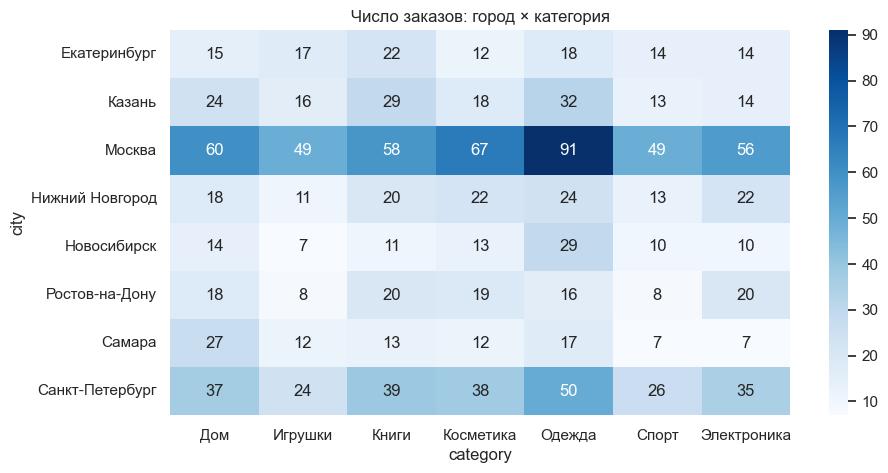

In [65]:
piv = df.pivot_table(index='city', columns='category',
                     values='order_id', aggfunc='count')
plt.figure(figsize=(10, 5))
sns.heatmap(piv, annot=True, fmt='g', cmap='Blues')
plt.title('Число заказов: город × категория');
# Ожидаемый результат: самая горячая клетка — Москва × Одежда (91 заказ)

**Вывод:** Самое «горячее» сочетание — Москва × Одежда (около 91 заказа): и заказов в Москве больше всех, и одежда — самая популярная категория.

### <font color='DarkOrange'>Задание 9 [3 балла]</font>

Постройте **тепловую карту** среднего чека «сегмент × категория»: по строкам — сегмент (`segment`), по столбцам — категория (`category`), в клетках — средний чек (`amount`); подпишите числа в клетках. В каком сочетании средний чек максимальный?

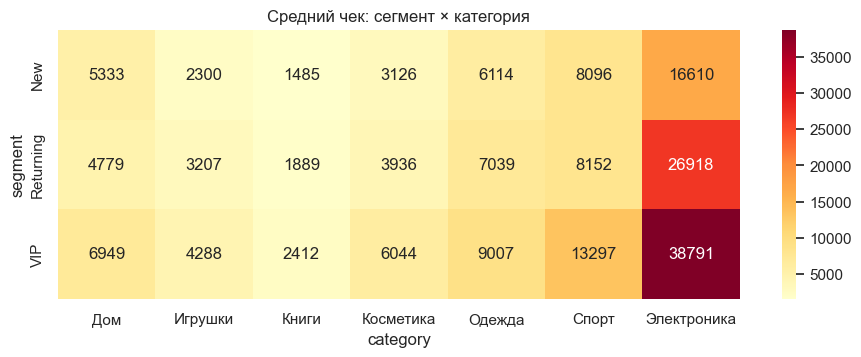

In [66]:
piv = df.pivot_table(index='segment', columns='category',
                     values='amount', aggfunc='mean').round()
plt.figure(figsize=(11, 3.5))
sns.heatmap(piv, annot=True, fmt='g', cmap='YlOrRd')
plt.title('Средний чек: сегмент × категория');
# Ожидаемый результат: самая горячая клетка — VIP × Электроника (~38800);
# электроника у всех сегментов дороже всего, а VIP везде платят больше

**Вывод:** Самый высокий средний чек — у VIP в «Электронике» (~39 000): электроника дороже всех категорий, а VIP в каждой категории платят больше остальных сегментов.

### <font color='DarkOrange'>Задание 10 [5 баллов]</font>

Соберите **портрет магазина на одном полотне**: сетка **2×2** из четырёх разных графиков. Например: выручка по каналам (`channel`), доли устройств (`device`), распределение сумм (`amount`), средний чек по сегментам (`segment`). В выводе опишите магазин 2–3 предложениями.

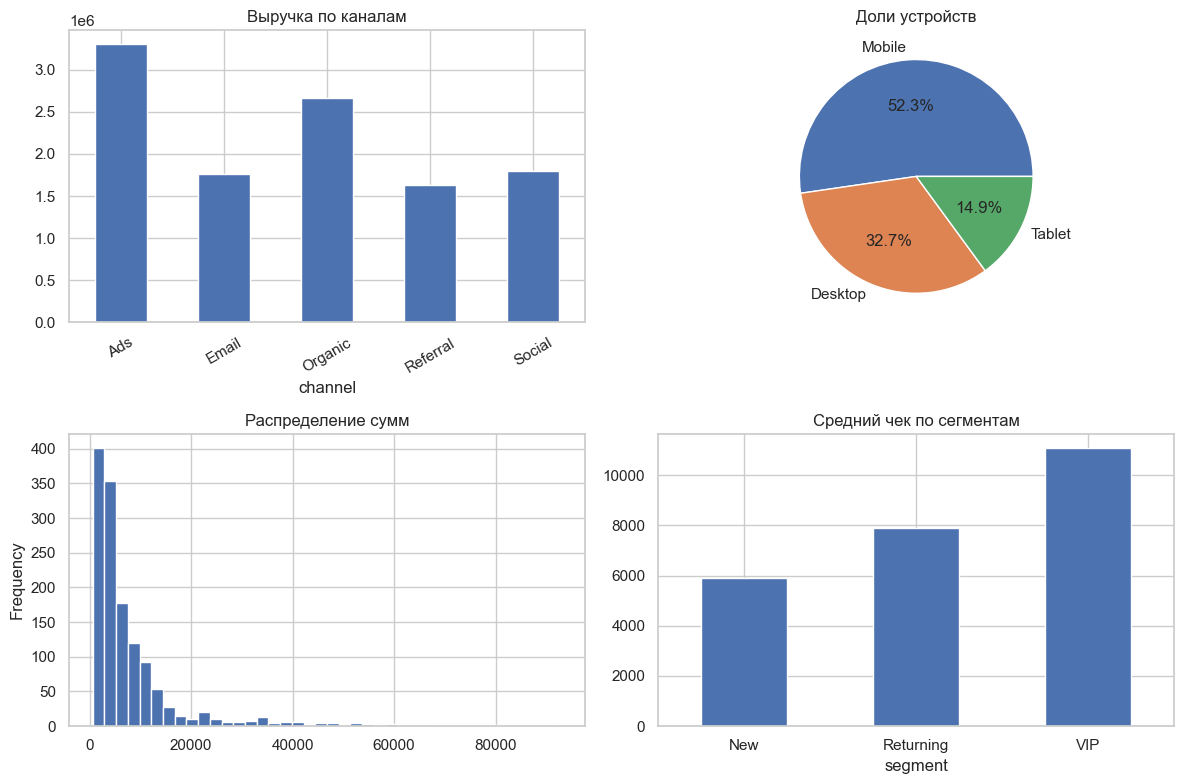

In [67]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df.groupby('channel')['amount'].sum().plot(kind='bar', ax=axes[0, 0],
                                           rot=30, title='Выручка по каналам')
df['device'].value_counts().plot(kind='pie', ax=axes[0, 1], ylabel='',
                                 autopct='%1.1f%%', title='Доли устройств')
df['amount'].plot(kind='hist', bins=40, ax=axes[1, 0], title='Распределение сумм')
df.groupby('segment')['amount'].mean().plot(kind='bar', ax=axes[1, 1],
                                            rot=0, title='Средний чек по сегментам')
plt.tight_layout();
# Ожидаемый результат: 4 графика в сетке 2x2 — каналы (лидер Ads),
# устройства (Mobile ~52%), скошенное распределение сумм, чек по сегментам (VIP выше)

**Вывод:** Магазин мобильный (более половины заказов с телефона) и «вечерний»; больше всего выручки приносит канал Ads; суммы заказов сильно скошены вправо, а самый ценный сегмент — VIP с заметно более высоким средним чеком.